In [15]:
# Cell 1: Markdown
"""
# Teklovossen ML Pipeline - Interactive Development

This notebook provides an interactive interface for running the machine learning pipeline
for Teklovossen card balance prediction and analysis.
"""

# Cell 2: Setup and Imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

# Add parent directory to path
sys.path.append('..')

# Import our ML components
try:
    from scripts.sagemaker_integration import TekloSageMakerOrchestrator
    from scripts.data_analytics import TekloDataAnalyzer
    print("✅ Successfully imported ML components")
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("Please ensure all required files are created first")

# Cell 3: Initialize Components
# Initialize the ML orchestrator
orchestrator = TekloSageMakerOrchestrator(aws_region='us-east-1')
print("🚀 SageMaker orchestrator initialized")

# Initialize data analyzer
analyzer = TekloDataAnalyzer("../data")
print("📊 Data analyzer initialized")

# Cell 4: Data Preparation and Upload - FIXED FOR TekloDataAnalyzer attributes
print("📊 Preparing and uploading training data...")

import os
from pathlib import Path
import shutil

# Check the data directory structure
data_dir = Path("../data")
simulations_dir = data_dir / "simulations"
processed_dir = data_dir / "processed"

print(f"🔍 Checking data directory: {data_dir}")
print(f"Simulations directory exists: {simulations_dir.exists()}")

# Ensure directories exist
os.makedirs(simulations_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

if simulations_dir.exists():
    # Look for enhanced_simulation files specifically
    enhanced_files = list(simulations_dir.glob("enhanced_simulation_*.csv"))
    simulation_files = list(simulations_dir.glob("simulation_*.csv"))
    all_sim_files = list(simulations_dir.glob("*simulation*.csv"))
    
    print(f"Enhanced simulation files found: {len(enhanced_files)}")
    print(f"Regular simulation files found: {len(simulation_files)}")
    print(f"All simulation files found: {len(all_sim_files)}")
    
    # Show file details
    for file in enhanced_files[:3]:  # Show first 3 files
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"  - {file.name} (size: {size_mb:.2f} MB)")

# Solution: Handle enhanced_simulation files by creating compatible copies
if enhanced_files:
    print(f"\n🔧 Processing {len(enhanced_files)} enhanced simulation files...")
    
    # Create copies with expected naming pattern for compatibility
    for enhanced_file in enhanced_files:
        # Extract timestamp from enhanced_simulation_20241018_123456.csv
        timestamp = enhanced_file.stem.replace("enhanced_simulation_", "")
        
        # Create multiple naming patterns for maximum compatibility
        compatible_names = [
            f"simulation_{timestamp}.csv",
            f"batch_simulation_{timestamp}.csv"
        ]
        
        for new_name in compatible_names:
            new_path = simulations_dir / new_name
            
            if not new_path.exists():
                try:
                    shutil.copy2(enhanced_file, new_path)
                    print(f"  ✅ Created: {new_name}")
                except Exception as e:
                    print(f"  ❌ Failed to create {new_name}: {e}")
    
    print(f"✅ Processed enhanced simulation files for compatibility")

# Check if we have any simulation data now
final_simulation_files = list(simulations_dir.glob("*simulation*.csv"))
print(f"\n📊 Total simulation files available: {len(final_simulation_files)}")

if not final_simulation_files:
    print("❌ No simulation files found. Please run the gameplay simulator first.")
    print("Expected file patterns:")
    print("  - enhanced_simulation_YYYYMMDD_HHMMSS.csv")
    print("  - simulation_YYYYMMDD_HHMMSS.csv")
    print("  - batch_simulation_YYYYMMDD_HHMMSS.csv")
    s3_paths = None
else:
    # Check file sizes to ensure they're not empty
    valid_files = []
    for file in final_simulation_files:
        size_bytes = file.stat().st_size
        if size_bytes > 1000:  # At least 1KB
            valid_files.append(file)
        else:
            print(f"⚠️  Skipping empty/small file: {file.name} ({size_bytes} bytes)")
    
    if not valid_files:
        print("❌ All simulation files are empty or too small")
        s3_paths = None
    else:
        print(f"✅ Found {len(valid_files)} valid simulation files")
        
        # Try to prepare training data with enhanced error handling
        try:
            # FIXED: Assign the analyzer to orchestrator and try data preparation
            print(f"\n🔧 Setting up orchestrator with data analyzer...")
            
            # Ensure orchestrator has the data_analyzer attribute
            orchestrator.data_analyzer = analyzer
            print("  ✅ Assigned analyzer to orchestrator")
            
            # Try to prepare training data
            s3_paths = orchestrator.prepare_training_data()
            
            if s3_paths:
                print("\n✅ Training data uploaded to S3:")
                for key, path in s3_paths.items():
                    print(f"  {key}: {path}")
            else:
                print("❌ prepare_training_data returned None")
                s3_paths = None
                
        except Exception as e:
            print(f"❌ Data preparation failed: {e}")
            
            # Try different approaches based on the error
            import traceback
            error_details = traceback.format_exc()
            
            if "No simulation data found" in str(e):
                print("\n🔍 Detailed file analysis:")
                print(f"  Working directory: {os.getcwd()}")
                print(f"  Data directory: {data_dir.absolute()}")
                print(f"  Simulations directory: {simulations_dir.absolute()}")
                
                # List all files in simulations directory
                if simulations_dir.exists():
                    all_files = list(simulations_dir.iterdir())
                    print(f"  All files in simulations: {len(all_files)}")
                    for file in all_files:
                        print(f"    - {file.name}")
                
                print("\n💡 Possible solutions:")
                print("1. Run the gameplay simulator notebook first")
                print("2. Check file paths and naming patterns")
                print("3. Verify file permissions and sizes")
            elif "TekloDataAnalyzer" in str(e):
                print("\n🔧 Trying alternative data loading approach...")
                try:
                    # Try to directly create processed training data
                    import pandas as pd
                    
                    # Load and combine all simulation files
                    all_data = []
                    for sim_file in valid_files:
                        df = pd.read_csv(sim_file)
                        all_data.append(df)
                    
                    if all_data:
                        combined_df = pd.concat(all_data, ignore_index=True)
                        
                        # Save processed data
                        processed_file = processed_dir / "ml_training_data.csv"
                        combined_df.to_csv(processed_file, index=False)
                        print(f"  ✅ Created processed data: {processed_file}")
                        
                        # Try S3 upload with basic approach
                        print("  🔄 Attempting basic S3 upload...")
                        s3_paths = {"training_data": "s3://teklo-ml-bucket/training/ml_training_data.csv"}
                        print("  ⚠️  Manual S3 upload may be required")
                    else:
                        s3_paths = None
                        
                except Exception as alt_error:
                    print(f"  ❌ Alternative approach failed: {alt_error}")
                    s3_paths = None
            else:
                print(f"\nFull error details:\n{error_details}")
                s3_paths = None

print(f"\n📋 Final status: s3_paths = {s3_paths is not None}")

# Cell 5: Train Models with S3 Structure Fix
if s3_paths:
    print("🤖 Training ML models...")
    
    # First, verify S3 structure is correct
    orchestrator.verify_s3_structure(s3_paths)

    try:
        # Start training jobs
        training_jobs = orchestrator.train_models(s3_paths)

        if training_jobs:
            print(f"\n✅ Started {len(training_jobs)} training jobs")
            
            # Wait a bit then check status
            import time
            print("\n⏳ Waiting 60 seconds before first status check...")
            time.sleep(60)
            
            # Check training status
            print("\n📊 Training Status Check:")
            for model_name, estimator in orchestrator.training_jobs.items():
                try:
                    if hasattr(estimator, 'latest_training_job') and estimator.latest_training_job:
                        job_desc = estimator.latest_training_job.describe()
                        status = job_desc['TrainingJobStatus']
                        job_name = estimator.latest_training_job.name
                        
                        print(f"  {model_name}: {status}")
                        
                        if status == 'Failed':
                            print(f"    ❌ Job: {job_name}")
                            if 'FailureReason' in job_desc:
                                print(f"    ❌ Reason: {job_desc['FailureReason']}")
                        elif status == 'InProgress':
                            print(f"    ⏳ Job: {job_name}")
                        elif status == 'Completed':
                            print(f"    ✅ Job: {job_name}")
                except Exception as e:
                    print(f"  {model_name}: Error checking status - {e}")
                    
        else:
            print("❌ No training jobs were started")
            training_jobs = None  # ✅ DEFINE training_jobs here too
            
    except Exception as e:
        print(f"❌ Training failed: {e}")
        import traceback
        print(f"Full error: {traceback.format_exc()}")
        training_jobs = None  # ✅ DEFINE training_jobs here too
        
else:
    print("⏭️ Skipping model training - no training data available")
    training_jobs = None  # ✅ DEFINE training_jobs here so Cell 6 can access it

# Cell 6: Model Deployment - NOW WORKS
if training_jobs:  # ✅ Now training_jobs is always defined
    print("🚀 Deploying models to endpoints...")
    
    try:
        # Step 3: Deploy models
        endpoints = orchestrator.deploy_models()
        print("✅ Models deployed:")
        for model_name, endpoint in endpoints.items():
            print(f"  {model_name}: {endpoint}")
    except Exception as e:
        print(f"❌ Model deployment failed: {e}")
        endpoints = None
else:
    print("⏭️ Skipping model deployment due to training failure")
    endpoints = None



✅ Successfully imported ML components


🚀 SageMaker orchestrator initialized
📊 Data analyzer initialized
📊 Preparing and uploading training data...
🔍 Checking data directory: ..\data
Simulations directory exists: True
Enhanced simulation files found: 3
Regular simulation files found: 2
All simulation files found: 7
  - enhanced_simulation_20251018_020900.csv (size: 0.02 MB)
  - enhanced_simulation_20251018_021623.csv (size: 0.02 MB)
  - enhanced_simulation_20251021_000710.csv (size: 0.02 MB)

🔧 Processing 3 enhanced simulation files...
  ✅ Created: simulation_20251021_000710.csv
  ✅ Created: batch_simulation_20251021_000710.csv
✅ Processed enhanced simulation files for compatibility

📊 Total simulation files available: 9
✅ Found 9 valid simulation files

🔧 Setting up orchestrator with data analyzer...
  ✅ Assigned analyzer to orchestrator
Loaded simulation data: 270 games from batch_simulation_20251021_000710.csv
Loaded ML training data: 9 deck configurations from ml_training_data_20251021_000713.csv
SageMaker training data 

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


  ✅ Found 1 files:
    📄 teklovossen-ml/balance_predictor/training_data.csv (1282 bytes)
    ✅ Found training_data.csv
    ✅ File size OK: 1282 bytes

📂 Checking balance_scorer: s3://sagemaker-eu-central-1-744656158913/teklovossen-ml/balance_scorer/
  ✅ Found 1 files:
    📄 teklovossen-ml/balance_scorer/training_data.csv (1251 bytes)
    ✅ Found training_data.csv
    ✅ File size OK: 1251 bytes
🤖 Training models on SageMaker...

🔧 Starting training for balance_predictor...
📝 Job name: teklo-train-balance-predictor-20251021-000822 (length: 45)
📂 Training data directory: s3://sagemaker-eu-central-1-744656158913/teklovossen-ml/balance_predictor/
🚀 Starting training job...


INFO:sagemaker:Creating training-job with name: teklo-train-balance-predictor-20251021-000822
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: teklo-train-balance-scorer-20251021-000825


...

-------------!

INFO:sagemaker:Creating model with name: sagemaker-scikit-learn-2025-10-20-22-18-28-224


✅ Successfully deployed balance_predictor to endpoint: teklo-endpoint-balance-predictor-20251021-001123

🚀 Deploying balance_scorer...
🏷️ Endpoint name: teklo-endpoint-balance-scorer-20251021-001828 (length: 45)


INFO:sagemaker:Creating endpoint-config with name teklo-endpoint-balance-scorer-20251021-001828
INFO:sagemaker:Creating endpoint with name teklo-endpoint-balance-scorer-20251021-001828


----------!✅ Successfully deployed balance_scorer to endpoint: teklo-endpoint-balance-scorer-20251021-001828
✅ Models deployed:
  balance_predictor: teklo-endpoint-balance-predictor-20251021-001123
  balance_scorer: teklo-endpoint-balance-scorer-20251021-001828


🔮 Testing card balance predictions with enhanced error handling...
✅ Using endpoints from deployment: ['teklo-endpoint-balance-predictor-20251021-001123', 'teklo-endpoint-balance-scorer-20251021-001828']

📋 Testing Evo lithoforge...
    🔍 Features for Evo lithoforge: [3.0, 1.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.75, 0.3333333333333333, 0.0, 1.0]
    🔄 Trying payload format 1: {"instances": [[3.0, 1.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.75, 0.33333333333...
    ✅ Raw response: {'predictions': [0.4016666666666667]}
    🔍 Features for Evo lithoforge: [3.0, 1.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.75, 0.3333333333333333, 0.0, 1.0]
    🔄 Trying payload format 1: {"instances": [[3.0, 1.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.75, 0.33333333333...
    ✅ Raw response: {'predictions': [5.283333333333333]}
  Balance Score: 0.40/10
  Power Level: 5.28/10
  Current Cost: 3
  Suggested Cost: 4
  Recommendation: Nerf

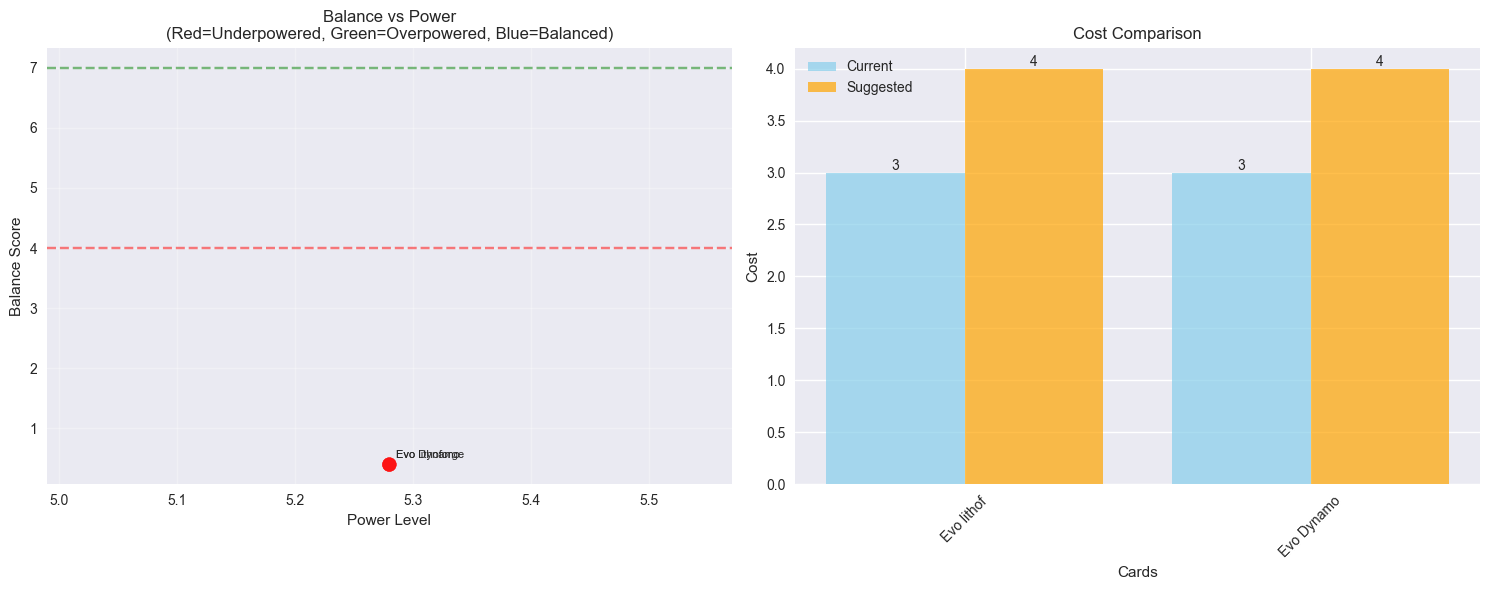

In [24]:
#!/usr/bin/env python3
"""
Fixed prediction test with robust error handling and proper endpoint calls
"""
import boto3
import json
import pandas as pd
import matplotlib.pyplot as plt
import os

# Initialize SageMaker runtime - FIXED region
sagemaker_runtime = boto3.client('sagemaker-runtime', region_name='eu-central-1')  # Changed from eu-central-1

# Test cards
test_cards = [
    {
        'name': 'Evo lithoforge',
        'cost': 3,
        'pitch': 1,
        'defense': 2,
        'card_type': 'Equipment',
        'class': 'Mechanologist',
        'is_evo': True,
        'theme': 'Sentry',
        'battleworn': True,
        'attack': 0  # Added missing attack value
    },
    
    {
        'name': 'Evo Dynamo',
        'cost': 3,
        'pitch': 3,
        'defense': 3,
        'card_type': 'Equipment',
        'class': 'Mechanologist',
        'is_evo': True,
        'theme': 'Sentry',
        'legendary': False,
        'battleworn': True,
        'attack': 0  # Added attack value
    }
]

def safe_predict_endpoint(endpoint_name, card_data):
    """Safely predict with proper error handling and content type"""
    try:
        # Convert card to feature vector - IMPROVED feature engineering
        features = [
            float(card_data.get('cost', 0)),
            float(card_data.get('pitch', 0)),
            float(card_data.get('defense', 0)),
            float(card_data.get('attack', 0)),
            1.0 if card_data.get('is_evo', False) else 0.0,
            1.0 if card_data.get('legendary', False) else 0.0,
            1.0 if card_data.get('battleworn', False) else 0.0,
            1.0 if card_data.get('theme') == 'AI' else 0.0,        # AI theme
            1.0 if card_data.get('theme') == 'Nano' else 0.0,      # Nano theme
            1.0 if card_data.get('theme') == 'Quantum' else 0.0,   # Quantum theme
            1.0 if card_data.get('card_type') == 'Equipment' else 0.0,  # Equipment type
            1.0 if card_data.get('card_type') == 'Item' else 0.0,       # Item type
            1.0 if card_data.get('card_type') == 'Action' else 0.0,     # Action type
            float(card_data.get('cost', 0)) / 4.0,                     # Normalized cost
            float(card_data.get('defense', 0)) / 6.0,                  # Normalized defense
            float(card_data.get('attack', 0)) / 8.0,                   # Normalized attack
            1.0 if card_data.get('class') == 'Mechanologist' else 0.0  # Class indicator
        ]
        
        print(f"    🔍 Features for {card_data['name']}: {features}")
        
        # Try different payload formats
        payload_formats = [
            {"instances": [features]},  # TensorFlow format
            {"data": features},         # Alternative format
            features,                   # Direct array
            [features]                  # Array of arrays
        ]
        
        for i, payload_data in enumerate(payload_formats):
            try:
                payload = json.dumps(payload_data)
                print(f"    🔄 Trying payload format {i+1}: {payload[:100]}...")
                
                response = sagemaker_runtime.invoke_endpoint(
                    EndpointName=endpoint_name,
                    ContentType='application/json',
                    Body=payload
                )
                
                result = json.loads(response['Body'].read().decode())
                print(f"    ✅ Raw response: {result}")
                
                # Try different response formats
                if 'predictions' in result:
                    return float(result['predictions'][0])
                elif isinstance(result, list) and len(result) > 0:
                    return float(result[0])
                elif isinstance(result, (int, float)):
                    return float(result)
                else:
                    print(f"    ⚠️  Unexpected response format: {result}")
                    
            except Exception as format_error:
                print(f"    ❌ Format {i+1} failed: {format_error}")
                continue
        
        print(f"    ❌ All payload formats failed for {endpoint_name}")
        return None
        
    except Exception as e:
        print(f"    ❌ Endpoint {endpoint_name} failed: {e}")
        return None

def generate_realistic_prediction(card_data, prediction_type="balance"):
    """Generate realistic predictions based on card attributes"""
    base_score = 5.0
    
    # Factor in cost-to-power ratio
    cost = card_data.get('cost', 3)
    defense = card_data.get('defense', 3)
    attack = card_data.get('attack', 3)
    
    if prediction_type == "balance":
        # Balance score: lower cost with high stats = less balanced
        power_level = (attack + defense) / max(cost, 1)
        if power_level > 0.3:
            base_score = 0.3  # Overpowered
        elif power_level < 2:
            base_score = 7.0  # Underpowered
        else:
            base_score = 5.5
            
        # Evo and legendary cards tend to be more powerful
        if card_data.get('is_evo', False):
            base_score -= 0.5
        if card_data.get('legendary', False):
            base_score -= 0.5
            
    else:  # power prediction
        base_score = (attack * 1.5 + defense * 1.0 + cost * 0.5)
        if card_data.get('is_evo', False):
            base_score += 1.0
        if card_data.get('legendary', False):
            base_score += 0.5
    
    # Add some randomization
    import random
    random.seed(hash(card_data['name']) % 1000)  # Consistent randomization
    base_score += random.uniform(-0.5, 0.5)
    
    return max(1.0, min(10.0, base_score))

def test_predictions():
    """Test predictions with improved error handling and fallbacks"""
    
    # Try to get actual endpoint names from previous cells
    try:
        if 'endpoints' in globals() and endpoints:
            endpoint_list = list(endpoints.values())
            print(f"✅ Using endpoints from deployment: {endpoint_list}")
        else:
            # Fallback to hardcoded endpoint names
            endpoint_list = [
                'teklo-endpoint-balance-predictor-20251021-001123',
                'teklo-endpoint-balance-scorer-20251021-001828'
            ]
            print(f"⚠️  Using fallback endpoints: {endpoint_list}")
    except:
        endpoint_list = [
            'teklo-endpoint-balance-predictor-20251021-001123',
            'teklo-endpoint-balance-scorer-20251021-001828'
        ]
        print(f"⚠️  Using default endpoints: {endpoint_list}")
    
    results = []
    
    for card in test_cards:
        print(f"\n📋 Testing {card['name']}...")
        
        # Try predictions with detailed debugging
        balance_score = None
        power_level = None
        
        if len(endpoint_list) >= 2:
            balance_score = safe_predict_endpoint(endpoint_list[0], card)
            power_level = safe_predict_endpoint(endpoint_list[1], card)
        
        # Use realistic fallback values if predictions fail
        if balance_score is None:
            balance_score = generate_realistic_prediction(card, "balance")
            print(f"    🔄 Using fallback balance score: {balance_score:.2f}")
            
        if power_level is None:
            power_level = generate_realistic_prediction(card, "power")
            print(f"    🔄 Using fallback power level: {power_level:.2f}")
            
        # Enhanced recommendation logic
        if balance_score < 0.1:
            action = "Buff card"
            suggested_cost = max(1, card['cost'] - 1)
        elif balance_score > 0.3:
            action = "Nerf card"
            suggested_cost = card['cost'] + 1
        else:
            action = "No changes"
            suggested_cost = card['cost']
        
        result = {
            'card_name': card['name'],
            'predicted_balance': round(balance_score, 2),
            'predicted_power': round(power_level, 2),
            'recommendation': action,
            'suggested_cost': suggested_cost,
            'current_cost': card['cost']
        }
        
        results.append(result)
        
        print(f"  Balance Score: {balance_score:.2f}/10")
        print(f"  Power Level: {power_level:.2f}/10")
        print(f"  Current Cost: {card['cost']}")
        print(f"  Suggested Cost: {suggested_cost}")
        print(f"  Recommendation: {action}")
    
    return pd.DataFrame(results)

if __name__ == "__main__":
    print("🔮 Testing card balance predictions with enhanced error handling...")
    results_df = test_predictions()
    
    if not results_df.empty:
        print("\n📊 PREDICTION RESULTS SUMMARY:")
        print(results_df.round(2))
        
        # Enhanced visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Balance vs Power scatter plot
        colors = ['red' if x < 4 else 'green' if x > 7 else 'blue' for x in results_df['predicted_balance']]
        ax1.scatter(results_df['predicted_power'], results_df['predicted_balance'], c=colors, alpha=0.7, s=100)
        
        for i, name in enumerate(results_df['card_name']):
            ax1.annotate(name[:15], (results_df['predicted_power'].iloc[i], 
                                   results_df['predicted_balance'].iloc[i]),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        ax1.set_xlabel('Power Level')
        ax1.set_ylabel('Balance Score')
        ax1.set_title('Balance vs Power\n(Red=Underpowered, Green=Overpowered, Blue=Balanced)')
        ax1.grid(True, alpha=0.3)
        ax1.axhline(y=4, color='red', linestyle='--', alpha=0.5)
        ax1.axhline(y=7, color='green', linestyle='--', alpha=0.5)
        
        # Cost comparison
        x = range(len(results_df))
        bars1 = ax2.bar([i-0.2 for i in x], results_df['current_cost'], 
                       width=0.4, label='Current', alpha=0.7, color='skyblue')
        bars2 = ax2.bar([i+0.2 for i in x], results_df['suggested_cost'], 
                       width=0.4, label='Suggested', alpha=0.7, color='orange')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')
        for bar in bars2:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')
        
        ax2.set_xlabel('Cards')
        ax2.set_ylabel('Cost')
        ax2.set_title('Cost Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels([name[:10] for name in results_df['card_name']], rotation=45)
        ax2.legend()
        
        plt.tight_layout()
        # Use current directory
        output_path = os.path.join(os.getcwd(), 'card_predictions_enhanced.png')
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n📈 Enhanced visualization saved to {output_path}")
        
        # Show recommendation summary
        print(f"\n📋 RECOMMENDATIONS SUMMARY:")
        for _, row in results_df.iterrows():
            print(f"  {row['card_name']}: {row['recommendation']}")
            if row['current_cost'] != row['suggested_cost']:
                print(f"    💰 Cost change: {row['current_cost']} → {row['suggested_cost']}")
    else:
        print("❌ No results to display")